<a href="https://colab.research.google.com/github/ankurdev1-drth/Deep_Learning-/blob/main/Building_Neural_Network_Using_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## PyTorch Fundamentals

Note:
- core data structure Pytorch  tensor
- tensor:
   - multidimensional array with a shape and a data type, used for numerical computations
   - it can live on a GPU
   - it supports auto-differentiation
   - a tensor can contain floats, integers, booleans, or complex numbers—just one data type per tensor.
   - Indexing works just like for NumPy arrays

### PyTorch Tensors

In [1]:
import torch

In [2]:
X = torch.tensor([[1.0, 4.0, 7.0], [2.0, 3.0, 6.0]])

In [3]:
X

tensor([[1., 4., 7.],
        [2., 3., 6.]])

In [4]:
X.shape

torch.Size([2, 3])

In [5]:
X.dtype

torch.float32

In [6]:
X[0,1]

tensor(4.)

In [7]:
X[1,1]

tensor(3.)

In [8]:
X[:, 1]  #shows everything from column 1

tensor([4., 3.])

In [9]:
10 *(X + 1.0) # itemise addition and multiplication

tensor([[20., 50., 80.],
        [30., 40., 70.]])

In [10]:
X.exp() #itemwise exponential

tensor([[   2.7183,   54.5981, 1096.6332],
        [   7.3891,   20.0855,  403.4288]])

In [11]:
X.mean()

tensor(3.8333)

In [12]:
X.max(dim=0) #max values along dimension 0 (max value per column)

torch.return_types.max(
values=tensor([2., 4., 7.]),
indices=tensor([1, 0, 0]))

In [13]:
X @ X.T #matrix transpose and matrix multiplication

tensor([[66., 56.],
        [56., 49.]])

Note:
- PyTorch prefers the argument name dim in operations such as max() , but it also supports axis (as in NumPy or Pandas).
- You can also convert a tensor to a NumPy array using the numpy() method, and create a tensor from a NumPy array
- torch.FloatTensor()  automatically converts the array to 32 bits
- modification of a tensor in place using indexing and slicing is possible
- PyTorch’s API provides many in-place operations, such as abs_() , sqrt_() , and zero_() , which modify the input tensor directly
-

In [14]:
import numpy as np
X.numpy()

array([[1., 4., 7.],
       [2., 3., 6.]], dtype=float32)

In [15]:
torch.tensor(np.array([[1., 4., 7.], [2., 3., 6.]]), dtype=torch.float32)

tensor([[1., 4., 7.],
        [2., 3., 6.]])

In [16]:
X[:, 1] =  -99

In [17]:
X

tensor([[  1., -99.,   7.],
        [  2., -99.,   6.]])

In [18]:
X[1,  :] = 0

In [19]:
X

tensor([[  1., -99.,   7.],
        [  0.,   0.,   0.]])

In [20]:
X.relu_()  #here relu_() replaces all the negative numbers with 0

tensor([[1., 0., 7.],
        [0., 0., 0.]])

## Hardware Acceleration

In [21]:
if torch.cuda.is_available():
    device="cuda"
elif torch.backends.mps.is_available():
    device="mps"
else:
    device="cpu"

In [22]:
M = torch.tensor([[1., 2., 3.], [4., 5., 6.]])

In [23]:
M = M.to(device)

In [24]:
M.device #tells on which device tensor lives on

device(type='cuda', index=0)

We can create tensor on gpu using *device* argument

In [25]:
M = torch.tensor([[1., 2., 3.], [4., 5., 6.]], device=device)

In [26]:
M

tensor([[1., 2., 3.],
        [4., 5., 6.]], device='cuda:0')

Now all the operations will run on gpu

In [27]:
R = M @ M.T

In [28]:
R

tensor([[14., 32.],
        [32., 77.]], device='cuda:0')

The result R also lives on GPU instead of CPU that means we can perform multiple operations on GPU

In [29]:
#testing the speed of the multiplication matrix on
M = torch.rand((1000,1000)) # on cpu

In [30]:
%timeit M @ M.T

84.3 ms ± 30.8 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [31]:
M = torch.rand((1000, 1000), device="cuda")

In [32]:
%timeit M@M.T

639 µs ± 5.1 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


## Autograd (automatic gradient)

Note:
- It's an implementation of reverse-mode, auto-differentiation

In [33]:
#taking an example:
x = torch.tensor(5.0, requires_grad=True)
f = x**2
f

tensor(25., grad_fn=<PowBackward0>)

In [34]:
f.backward()

In [35]:
x.grad

tensor(10.)

backward()
function automatically computed the gradient f'(x) at the same
point x = 5.0.

Note:
- we told PyTorch that it’s a variable (not a constant) by specifying requires_grad=True
- tensor x is a leaf node
- f also carries a grad_fn attribute which represents the operation that created this tensor ( ** , power, hence the name PowBackward0),and which tells PyTorch how to backpropagate the gradients through this particular operation.
- we call f.backward() : this backpropagates the gradients through the computation graph, starting with f , and all the way back to the leaf nodes (just x in this case)


In [36]:
#performing gradient descent
learning_rate = 0.1
with torch.no_grad():
    x -= learning_rate * x.grad ##gradient descent step


Another way to avoid gradient computation is to use the variable’s detach()
method: this creates a new tensor detached from the computation graph, with
requires_grad=False , but still pointing to the same data in memory.

In [37]:
x_detached = x.detach()

In [38]:
x_detached -= learning_rate * x.grad

In [39]:
x_detached

tensor(3.)

In [40]:
X.tanh_()

tensor([[0.7616, 0.0000, 1.0000],
        [0.0000, 0.0000, 0.0000]])

In [41]:
X.sigmoid_()

tensor([[0.6817, 0.5000, 0.7311],
        [0.5000, 0.5000, 0.5000]])

In [42]:
x.grad.zero_()

tensor(0.)

In [43]:
learning_rate = 0.1
x = torch.tensor(5.0, requires_grad=True)
for iteration in range(100):
    f = x**2
    f.backward()
    with torch.no_grad():
        x -=learning_rate * x.grad # gradient descent step

    x.grad.zero_() #reset the gradients

In [44]:
t = torch.tensor(2, requires_grad = True, dtype = float)
z = t.cos()+1 # intermediate result
z += 1 # in-place operation
z.backward()


Note:
- operations—such as exp() , relu() , rsqrt() , sigmoid() , sqrt() ,tan() , and tanh() —save their outputs in the computation graph duringthe forward pass, then use these outputs to compute the gradients durin the backward pass.5 This means that you must not modify such an operation’s output in place, or you will get an error during the backward pass
- operations—such as abs() , cos() , log() , sin() , square() , and var() —save their inputs instead of their output.6 Such an operation
doesn’t care if you modify its output in place, but you must not modify its inputs in place before the backward pass
- rations—such as max() , min() , norm() , prod() , sgn() , and std() —save both the inputs and the outputs, so you must not modify
either of them in place before the backward pass.


## Implementing Linear Regression

### Linear Regression Using Tensors and Autograd

In [45]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

housing = fetch_california_housing()
X_trainf, X_test, y_trainf, y_test = train_test_split(housing.data, housing.target, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(X_trainf, y_trainf, random_state=42)

In [46]:
housing.data

array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]])

In [47]:
housing.target

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894])

In [48]:
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
X_valid = torch.FloatTensor(X_valid)
means = X_train.mean(dim=0, keepdims=True)
stds = X_train.std(dim=0, keepdims=True)
X_train = (X_train- means) / stds
X_valid = (X_valid - means) / stds
X_test = (X_test - means) / stds


In [49]:
# as the target is a 1D array we need to reshape he tensors to column vectors by adding  second dimension f size 1 :
y_train = torch.FloatTensor(y_train).reshape(-1,1)
y_test = torch.FloatTensor(y_test).reshape(-1,1)
y_valid = torch.FloatTensor(y_valid).reshape(-1,1)

In [50]:
y_train

tensor([[1.4420],
        [1.6870],
        [1.6210],
        ...,
        [0.6800],
        [0.6130],
        [1.9700]])

In [51]:
## creating the parameters of our linear regression

torch.manual_seed(42)
n_features = X_train.shape[1] # there are 8 input features
w = torch.randn((n_features, 1), requires_grad = True)
b = torch.tensor(0., requires_grad=True)

In [52]:
#training model with help of BGD(batch-gradient descent) using full training set at each step
learning_rate=0.4
n_epochs=20
for epoch in range(n_epochs):
    y_pred = X_train @ w + b   #running the forward pass
    loss = ((y_pred - y_train) **2).mean()
    loss.backward() # computing the gradients of the loss with regard to every model parameter. this is an autograd in action
    with torch.no_grad():
        b -= learning_rate * b.grad # performing gradient descent
        w -= learning_rate * w.grad # performing gradient descent
        b.grad.zero_() # reducing the gradients to zero
        w.grad.zero_()
    print(f"Epoch {epoch + 1}/ {n_epochs}, Loss: {loss.item()}") # .item method extracts the value of the scalar tensor

Epoch 1/ 20, Loss: 16.158456802368164
Epoch 2/ 20, Loss: 4.8793745040893555
Epoch 3/ 20, Loss: 2.255225419998169
Epoch 4/ 20, Loss: 1.3307634592056274
Epoch 5/ 20, Loss: 0.9680691957473755
Epoch 6/ 20, Loss: 0.8142675757408142
Epoch 7/ 20, Loss: 0.7417045831680298
Epoch 8/ 20, Loss: 0.7020701169967651
Epoch 9/ 20, Loss: 0.6765918731689453
Epoch 10/ 20, Loss: 0.6577965021133423
Epoch 11/ 20, Loss: 0.6426151990890503
Epoch 12/ 20, Loss: 0.6297222971916199
Epoch 13/ 20, Loss: 0.6184942126274109
Epoch 14/ 20, Loss: 0.6085968613624573
Epoch 15/ 20, Loss: 0.5998216867446899
Epoch 16/ 20, Loss: 0.592018723487854
Epoch 17/ 20, Loss: 0.5850691795349121
Epoch 18/ 20, Loss: 0.578873336315155
Epoch 19/ 20, Loss: 0.573345422744751
Epoch 20/ 20, Loss: 0.5684100389480591


In [53]:
# making predictions for the first three instances in the test set

X_new = X_test[:3] #pretending that these are new instances
with torch.no_grad():
    y_pred = X_new @ w + b # using the trained parameters to make predictions
y_pred


tensor([[0.8916],
        [1.6480],
        [2.6577]])

**with torch.no_grad()** PyTorch takes less ram as it doesn't need to keep track of the computation graph

## Linear Regression Using PyTorch's High-Level API

**torch.nn.Linear** class in PyTorch is used for implementation of Linear Regression

In [54]:
import torch.nn as nn

torch.manual_seed(42) #for getting reproducible results
model = nn.Linear(in_features=n_features, out_features=1)

In [55]:
model.bias

Parameter containing:
tensor([0.3117], requires_grad=True)

In [56]:
model.weight

Parameter containing:
tensor([[ 0.2703,  0.2935, -0.0828,  0.3248, -0.0775,  0.0713, -0.1721,  0.2076]],
       requires_grad=True)

In [57]:
for param in model.parameters():
  print(param)

Parameter containing:
tensor([[ 0.2703,  0.2935, -0.0828,  0.3248, -0.0775,  0.0713, -0.1721,  0.2076]],
       requires_grad=True)
Parameter containing:
tensor([0.3117], requires_grad=True)


In [58]:
model(X_train[:2])

tensor([[-0.4718],
        [ 0.1131]], grad_fn=<AddmmBackward0>)

In [59]:
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
mse = nn.MSELoss()

In [60]:
# writing a function to train the model
def train_bgd(model, optimizer, criterion, X_train, y_train, n_epochs):
  for epoch in range(n_epochs):
    y_pred = model(X_train)
    loss = criterion(y_pred, y_train)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    print(f"Epoch {epoch +1}/ {n_epochs}, Loss:{loss.item()}")

In [61]:
#calling the function to train the model
train_bgd(model, optimizer, mse, X_train, y_train, n_epochs)


Epoch 1/ 20, Loss:4.3378496170043945
Epoch 2/ 20, Loss:0.7802939414978027
Epoch 3/ 20, Loss:0.6253842115402222
Epoch 4/ 20, Loss:0.6060433983802795
Epoch 5/ 20, Loss:0.5956299304962158
Epoch 6/ 20, Loss:0.587356686592102
Epoch 7/ 20, Loss:0.5802990794181824
Epoch 8/ 20, Loss:0.5741382837295532
Epoch 9/ 20, Loss:0.5687101483345032
Epoch 10/ 20, Loss:0.5639079809188843
Epoch 11/ 20, Loss:0.5596511363983154
Epoch 12/ 20, Loss:0.5558737516403198
Epoch 13/ 20, Loss:0.5525194406509399
Epoch 14/ 20, Loss:0.5495392084121704
Epoch 15/ 20, Loss:0.5468900203704834
Epoch 16/ 20, Loss:0.544533908367157
Epoch 17/ 20, Loss:0.5424376726150513
Epoch 18/ 20, Loss:0.5405716300010681
Epoch 19/ 20, Loss:0.5389097332954407
Epoch 20/ 20, Loss:0.5374288558959961


In [62]:
#model training done! now making predictions by simply calling it like a function
X_new = X_test[:3] #pretend these are new instances
with torch.no_grad():
  y_pred = model(X_new) #use the trained model to make predictions
y_pred

tensor([[0.8061],
        [1.7116],
        [2.6973]])

## Implementing a Regression MLP

In [63]:
torch.manual_seed(42)
model = nn.Sequential(
    nn.Linear(n_features, 50),
    nn.ReLU(),
    nn.Linear(50, 40),
    nn.ReLU(),
    nn.Linear(40, 1)
)

In [64]:
learning_rate = 0.1
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
mse = nn.MSELoss()
train_bgd(model, optimizer, mse, X_train, y_train, n_epochs)

Epoch 1/ 20, Loss:5.045480251312256
Epoch 2/ 20, Loss:2.0523123741149902
Epoch 3/ 20, Loss:1.0039883852005005
Epoch 4/ 20, Loss:0.8570139408111572
Epoch 5/ 20, Loss:0.7740675210952759
Epoch 6/ 20, Loss:0.7225847244262695
Epoch 7/ 20, Loss:0.6893726587295532
Epoch 8/ 20, Loss:0.6669032573699951
Epoch 9/ 20, Loss:0.6507738828659058
Epoch 10/ 20, Loss:0.6383934020996094
Epoch 11/ 20, Loss:0.6281993389129639
Epoch 12/ 20, Loss:0.6193399429321289
Epoch 13/ 20, Loss:0.6113173365592957
Epoch 14/ 20, Loss:0.6038705706596375
Epoch 15/ 20, Loss:0.5968307852745056
Epoch 16/ 20, Loss:0.5901119112968445
Epoch 17/ 20, Loss:0.5836468935012817
Epoch 18/ 20, Loss:0.5774063467979431
Epoch 19/ 20, Loss:0.5713554620742798
Epoch 20/ 20, Loss:0.565444827079773


## Implementing Mini-Batch Gradient Descent Using DataLoaders

In [65]:
from torch.utils.data import TensorDataset, DataLoader
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)


In [66]:
torch.manual_seed(42)
model = nn.Sequential(
    nn.Linear(n_features, 50),
    nn.ReLU(),
    nn.Linear(50,30),
    nn.ReLU(),
    nn.Linear(30, 1)
)
model = model.to(device)

In [67]:
def train(model, optimizer, criterion, train_loader, n_epochs):
  model.train()
  for epoch in range(n_epochs):
    total_loss = 0
    for X_batch, y_batch in train_loader:
      X_batch, y_batch = X_batch.to(device), y_batch.to(device)
      y_pred = model(X_batch)
      loss = criterion(y_pred, y_batch)
      total_loss += loss.item()
      loss.backward()
      optimizer.step()
      optimizer.zero_grad()

    mean_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch + 1}/{n_epochs}, Loss: {mean_loss:.4f}")

In [68]:
train(model, optimizer, mse, train_loader, n_epochs)

Epoch 1/20, Loss: 5.7690
Epoch 2/20, Loss: 5.7701
Epoch 3/20, Loss: 5.7704
Epoch 4/20, Loss: 5.7692
Epoch 5/20, Loss: 5.7704
Epoch 6/20, Loss: 5.7691
Epoch 7/20, Loss: 5.7710
Epoch 8/20, Loss: 5.7692
Epoch 9/20, Loss: 5.7699
Epoch 10/20, Loss: 5.7698
Epoch 11/20, Loss: 5.7699
Epoch 12/20, Loss: 5.7690
Epoch 13/20, Loss: 5.7696
Epoch 14/20, Loss: 5.7699
Epoch 15/20, Loss: 5.7688
Epoch 16/20, Loss: 5.7712
Epoch 17/20, Loss: 5.7694
Epoch 18/20, Loss: 5.7704
Epoch 19/20, Loss: 5.7700
Epoch 20/20, Loss: 5.7702


## Model Evaluation

In [69]:
def evaluate(model, data_loader, metric_fn, aggregate_fn=torch.mean):
  model.eval()
  metrics=[]

  with torch.no_grad():
    for X_batch, y_batch in data_loader:
      X_batch, y_batch = X_batch.to(device), y_batch.to(device)
      y_pred = model(X_batch)
      metric = metric_fn(y_pred, y_batch)
      metrics.append(metric)
  return aggregate_fn(torch.stack(metrics))


In [70]:
#building 'TensorDataset' and `DataLoader` for validation set and pass it through evaluate() functionto compute the validation MSE:
valid_dataset = TensorDataset(X_valid, y_valid)
valid_loader = DataLoader(valid_dataset, batch_size=32)
valid_mse = evaluate(model, valid_loader, mse)
valid_mse


tensor(5.8225, device='cuda:0')

In [71]:
## valid_rmse = evaluate(model, valid_loader, rmse) can't do this because python doesn't have an inbuilt function for this
def rmse (y_pred, y_true):
  return((y_pred - y_true)**2).mean().sqrt()


In [72]:
evaluate(model, valid_loader, rmse)

tensor(2.3826, device='cuda:0')

In [73]:
valid_mse.sqrt()

tensor(2.4130, device='cuda:0')

In [74]:
evaluate(model, valid_loader, mse,
         aggregate_fn=lambda metrics:
         torch.sqrt(torch.mean(metrics))
         )

tensor(2.4130, device='cuda:0')

In [75]:
%pip install torchmetrics

In [76]:
import torchmetrics

def evaluate_tm(model, data_loader, metric):
  model.eval()
  metric.reset() #reset the metric at begining
  with torch.no_grad():
    for X_batch, y_batch in data_loader:
      X_batch,  y_batch = X_batch.to(device), y_batch.to(device)
      y_pred = model(X_batch)
      metric.update(y_pred, y_batch)  #update it at each iteration
  return metric.compute()

In [77]:
#creating an RMSE streaming metric, move it to the GPU, and use it to evluate the validation set:
rmse = torchmetrics.MeanSquaredError(squared=False).to(device)
evaluate_tm(model, valid_loader, rmse)

tensor(2.4131, device='cuda:0')

Epoch 1/20, train loss: 0.7826, train metric: 0.8847, valid metric: 0.6690
Epoch 2/20, train loss: 0.4362, train metric: 0.6605, valid metric: 0.6099
Epoch 3/20, train loss: 0.3930, train metric: 0.6269, valid metric: 0.6145
Epoch 4/20, train loss: 0.3759, train metric: 0.6132, valid metric: 0.5963
Epoch 5/20, train loss: 0.3649, train metric: 0.6040, valid metric: 0.5911
Epoch 6/20, train loss: 0.3598, train metric: 0.5999, valid metric: 0.5965
Epoch 7/20, train loss: 0.3530, train metric: 0.5941, valid metric: 0.6062
Epoch 8/20, train loss: 0.3495, train metric: 0.5911, valid metric: 0.6043
Epoch 9/20, train loss: 0.3454, train metric: 0.5877, valid metric: 0.5723
Epoch 10/20, train loss: 0.3416, train metric: 0.5845, valid metric: 0.6037
Epoch 11/20, train loss: 0.3400, train metric: 0.5830, valid metric: 0.5880
Epoch 12/20, train loss: 0.3362, train metric: 0.5799, valid metric: 0.5738
Epoch 13/20, train loss: 0.3352, train metric: 0.5788, valid metric: 0.5881
Epoch 14/20, train lo

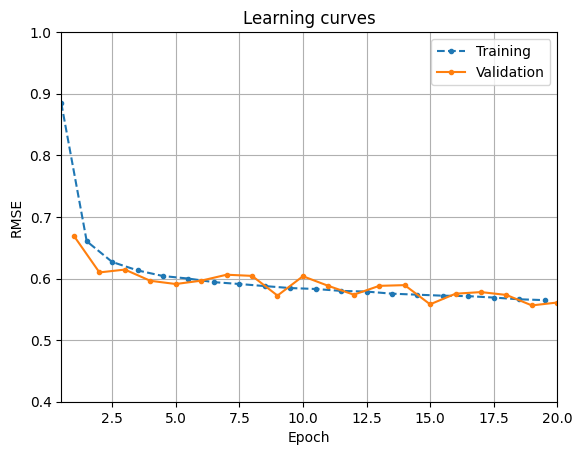

In [78]:
def train2(model, optimizer, criterion, metric, train_loader, valid_loader,
               n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.
        metric.reset()
        for X_batch, y_batch in train_loader:
            model.train()
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        mean_loss = total_loss / len(train_loader)
        history["train_losses"].append(mean_loss)
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_tm(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history

torch.manual_seed(42)
learning_rate = 0.01
model = nn.Sequential(
    nn.Linear(n_features, 50), nn.ReLU(),
    nn.Linear(50, 40), nn.ReLU(),
    nn.Linear(40, 30), nn.ReLU(),
    nn.Linear(30, 1)
)
model = model.to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0)
mse = nn.MSELoss()
rmse = torchmetrics.MeanSquaredError(squared=False).to(device)
history = train2(model, optimizer, mse, rmse, train_loader, valid_loader,
                 n_epochs)

# Since we compute the training metric
import matplotlib.pyplot as plt
plt.plot(np.arange(n_epochs) + 0.5, history["train_metrics"], ".--",
         label="Training")
plt.plot(np.arange(n_epochs) + 1.0, history["valid_metrics"], ".-",
         label="Validation")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.grid()
plt.title("Learning curves")
plt.axis([0.5, 20, 0.4, 1.0])
plt.legend()
plt.show()

## Building Nonsequential Models Using Custom Modules

In [79]:
class WideAndDeep(nn.Module):
  def __init__(self, n_features):
    super().__init__()
    self.deep_stack = nn.Sequential(
    nn.Linear(n_features, 50), nn.ReLU(),
    nn.Linear(50, 40), nn.ReLU(),
    )
    self.output_layer = nn.Linear(40 + n_features, 1)
  def forward(self, X):
    deep_output = self.deep_stack(X)
    wide_and_deep = torch.concat([X, deep_output], dim=1)
    return self.output_layer(wide_and_deep)

In [80]:
torch.manual_seed(42)
dingo = WideAndDeep(n_features).to(device)
learning_rate = 0.03

In [81]:
optimizer = torch.optim.SGD(dingo.parameters(), lr=learning_rate, momentum=0)
mse = nn.MSELoss()
rmse = torchmetrics.MeanSquaredError(squared=False).to(device)
history = train2(dingo,optimizer, mse, rmse, train_loader, valid_loader, n_epochs)

Epoch 1/20, train loss: 0.7270, train metric: 0.8527, valid metric: 2.5462
Epoch 2/20, train loss: 0.7434, train metric: 0.8624, valid metric: 9.4912
Epoch 3/20, train loss: 161.9915, train metric: 12.7309, valid metric: 2.8330
Epoch 4/20, train loss: 1.3397, train metric: 1.1576, valid metric: 1.3998
Epoch 5/20, train loss: 2.3967, train metric: 1.5484, valid metric: 0.9060
Epoch 6/20, train loss: 0.8729, train metric: 0.9344, valid metric: 2.0890
Epoch 7/20, train loss: 1.1036, train metric: 1.0507, valid metric: 1.1999
Epoch 8/20, train loss: 0.5369, train metric: 0.7327, valid metric: 4.4453
Epoch 9/20, train loss: 2.9575, train metric: 1.7201, valid metric: 3.4516
Epoch 10/20, train loss: 0.9674, train metric: 0.9837, valid metric: 1.1701
Epoch 11/20, train loss: 1.3154, train metric: 1.1469, valid metric: 41.9051
Epoch 12/20, train loss: 2.4622, train metric: 1.5695, valid metric: 6.0812
Epoch 13/20, train loss: 3.0214, train metric: 1.7386, valid metric: 3.4881
Epoch 14/20, trai

In [82]:
class WideAndDeepV2(nn.Module):
  def __init__(self, n_features):
    super().__init__() #super() method is used to access the methods of a super class in the derived class. and __init__() calls the constructor of the base class here
    self.deep_stack = nn.Sequential(
        nn.Linear(n_features, 50), nn.ReLU(),
        nn.Linear(50, 40), nn.ReLU(),
    )
    self.output_layer = nn.Linear(40 + n_features, 1)
  def forward(self,X):
      X_wide = X[:, :5]
      X_deep = X[:, 2:]
      deep_output = self.deep_stack(X_deep)
      wide_and_deep = torch.concat([X_wide, deep_output], dim=1)
      return self.output_layer(wide_and_deep)



## Building Models with Multiple Inputs

In [83]:
class WideAndDeepV3(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.deep_stack = nn.Sequential(
            nn.Linear(n_features - 2, 50), nn.ReLU(),
            nn.Linear(50, 40), nn.ReLU(),
            nn.Linear(40, 30), nn.ReLU(),
        )
        self.output_layer = nn.Linear(30 + 5, 1)

    def forward(self, X_wide, X_deep):
        deep_output = self.deep_stack(X_deep)
        wide_and_deep = torch.concat([X_wide, deep_output], dim=1)
        return self.output_layer(wide_and_deep)

Note:
- Here X_wide will contain the original features (without passing through an NN)
- X_deep: contains all the features which are passed through the neural network
- deep_output=[...] Take the deep input (X_deep), pass it through all the neural network layers in deep_stack, and store the resulting learned features in deep_output.
- wide_and_deep=[...] concatenates the original features and the features which have been passed through the NN
- returns ....   returns the Pass the combined features through the final layer to produce the prediction.

In [84]:
torch.manual_seed(42)
train_data_wd = TensorDataset(X_train[:, :5], X_train[:, 2:], y_train)
train_loader_wd = DataLoader(train_data_wd, batch_size=32, shuffle=True)
valid_data_wd = TensorDataset(X_valid[:, :5], X_valid[:, 2:], y_valid)
valid_loader_wd = DataLoader(valid_data_wd, batch_size=32)
test_data_wd = TensorDataset(X_test[:, :5], X_test[:, 2:], y_test)
test_loader_wd = DataLoader(test_data_wd, batch_size=32)

In [85]:
train_data_wd

In [86]:
def evaluate_multi_in(model, data_loader, metric):
    model.eval()
    metric.reset()  # reset the metric at the beginning
    with torch.no_grad():
        for X_batch_wide, X_batch_deep, y_batch in data_loader:
            X_batch_wide = X_batch_wide.to(device)
            X_batch_deep = X_batch_deep.to(device)
            y_batch = y_batch.to(device)
            y_pred = model(X_batch_wide, X_batch_deep)
            metric.update(y_pred, y_batch)  # update it at each iteration
    return metric.compute()  # compute the final result at the end

def train_multi_in(model, optimizer, criterion, metric, train_loader,
                   valid_loader, n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.
        metric.reset()
        for *X_batch_inputs, y_batch in train_loader:
            model.train()
            X_batch_inputs = [X.to(device) for X in X_batch_inputs]
            y_batch = y_batch.to(device)
            y_pred = model(*X_batch_inputs)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        mean_loss = total_loss / len(train_loader)
        history["train_losses"].append(mean_loss)
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_multi_in(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history

torch.manual_seed(42)
learning_rate = 0.01
model = WideAndDeepV3(n_features).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0)
mse = nn.MSELoss()
rmse = torchmetrics.MeanSquaredError(squared=False).to(device)
history = train_multi_in(model, optimizer, mse, rmse, train_loader_wd,
                         valid_loader_wd, n_epochs)

Epoch 1/20, train loss: 0.8366, train metric: 0.9148, valid metric: 0.6892
Epoch 2/20, train loss: 0.4627, train metric: 0.6803, valid metric: 0.6455
Epoch 3/20, train loss: 0.4319, train metric: 0.6572, valid metric: 0.6374
Epoch 4/20, train loss: 0.4259, train metric: 0.6525, valid metric: 0.6512
Epoch 5/20, train loss: 0.4120, train metric: 0.6420, valid metric: 0.6305
Epoch 6/20, train loss: 0.4040, train metric: 0.6356, valid metric: 0.6287
Epoch 7/20, train loss: 0.4005, train metric: 0.6330, valid metric: 0.6252
Epoch 8/20, train loss: 0.3976, train metric: 0.6306, valid metric: 0.6158
Epoch 9/20, train loss: 0.3883, train metric: 0.6230, valid metric: 0.7407
Epoch 10/20, train loss: 0.3866, train metric: 0.6218, valid metric: 0.6063
Epoch 11/20, train loss: 0.3752, train metric: 0.6125, valid metric: 0.5974
Epoch 12/20, train loss: 0.3704, train metric: 0.6087, valid metric: 0.5887
Epoch 13/20, train loss: 0.3677, train metric: 0.6063, valid metric: 0.5981
Epoch 14/20, train lo

In [88]:
#defining a custom dataset that returns a dictionary from input names to input values,
class WideAndDeepDataset(torch.utils.data.Dataset):
  def __init__(self, X_wide, X_deep, y):
      self.X_wide = X_wide
      self.X_deep = X_deep
      self.y = y

  def __len__(self):
      return len(self.y)

  def __getitem__(self, idx):
    input_dict = {"X_wide": self.X_wide[idx], "X_deep": self.X_deep[idx]}
    return input_dict, self.y[idx]


In [89]:
torch.manual_seed(42)
train_data_named = WideAndDeepDataset(
    X_wide=X_train[:, :5], X_deep=X_train[:, 2:], y=y_train)
train_loader_named = DataLoader(train_data_named, batch_size=32, shuffle=True)
valid_data_named = WideAndDeepDataset(
    X_wide=X_valid[:, :5], X_deep=X_valid[:, 2:], y=y_valid)
valid_loader_named = DataLoader(valid_data_named, batch_size=32)
test_data_named = WideAndDeepDataset(
    X_wide=X_test[:, :5], X_deep=X_test[:, 2:], y=y_test)
test_loader_named = DataLoader(test_data_named, batch_size=32)

In [90]:
def evaluate_named(model, data_loader, metric):
    model.eval()
    metric.reset()  # reset the metric at the beginning
    with torch.no_grad():
        for inputs, y_batch in data_loader:
            inputs = {name: X.to(device) for name, X in inputs.items()}
            y_batch = y_batch.to(device)
            y_pred = model(X_wide=inputs["X_wide"], X_deep=inputs["X_deep"])
            metric.update(y_pred, y_batch)
    return metric.compute()  # compute the final result at the end

def train_named(model, optimizer, criterion, metric, train_loader,
                   valid_loader, n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.
        metric.reset()
        for inputs, y_batch in train_loader:
            model.train()
            inputs = {name: X.to(device) for name, X in inputs.items()}
            y_batch = y_batch.to(device)
            y_pred = model(**inputs)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        mean_loss = total_loss / len(train_loader)
        history["train_losses"].append(mean_loss)
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_named(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history

torch.manual_seed(42)
learning_rate = 0.01
model = WideAndDeepV3(n_features).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0)
mse = nn.MSELoss()
rmse = torchmetrics.MeanSquaredError(squared=False).to(device)
history = train_named(model, optimizer, mse, rmse, train_loader_named,
                      valid_loader_named, n_epochs)

Epoch 1/20, train loss: 0.8366, train metric: 0.9148, valid metric: 0.6892
Epoch 2/20, train loss: 0.4627, train metric: 0.6803, valid metric: 0.6455
Epoch 3/20, train loss: 0.4319, train metric: 0.6572, valid metric: 0.6374
Epoch 4/20, train loss: 0.4259, train metric: 0.6525, valid metric: 0.6512
Epoch 5/20, train loss: 0.4120, train metric: 0.6420, valid metric: 0.6305
Epoch 6/20, train loss: 0.4040, train metric: 0.6356, valid metric: 0.6287
Epoch 7/20, train loss: 0.4005, train metric: 0.6330, valid metric: 0.6252
Epoch 8/20, train loss: 0.3976, train metric: 0.6306, valid metric: 0.6158
Epoch 9/20, train loss: 0.3883, train metric: 0.6230, valid metric: 0.7407
Epoch 10/20, train loss: 0.3866, train metric: 0.6218, valid metric: 0.6063
Epoch 11/20, train loss: 0.3752, train metric: 0.6125, valid metric: 0.5974
Epoch 12/20, train loss: 0.3704, train metric: 0.6087, valid metric: 0.5887
Epoch 13/20, train loss: 0.3677, train metric: 0.6063, valid metric: 0.5981
Epoch 14/20, train lo